# Analyst-Dispersion — a quantitative teardown 🔬
### Dispersion = (high − low) / |mean| EPS estimate · low-minus-high tercile long-short across 1/3/6/12-mo · one-sample *t* + label-shuffle placebo + Spearman · the 12-mo wrong-way monotonicity · costs · a seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_dispersion_lose%3F: Mixed](https://img.shields.io/badge/Does_dispersion_lose%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Diether-Malloy-Scherbina (2002) puzzle is a **real academic effect** — so the job here is the *data autopsy*: show exactly why a free, single-snapshot, survivor-tilted cross-section can't confirm it, where the lone significant window comes from, and why it is **Weak, not Real**.

> ⚠️ **Data + survivorship note.** Fixed **40-name large-cap** basket, names still trading in 2026 (a *survivor* panel that tilts the loud/high-dispersion leg toward winners). Crucially, yfinance gives only a **current dispersion snapshot** — no history — so the sort is dispersion-today vs **trailing** return (contemporaneous, not forward). Real data: yfinance `earnings_estimate` (0y) + daily closes, 2015→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from analyst_dispersion import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DISP, PRICES = data.load_real()
    FR = data.trailing_returns(PRICES, DISP)        # dispersion + trailing ret_<H> columns
else:
    DISP = PRICES = FR = None
print("real dispersion cache present:", HAVE_REAL,
      "| names:", (0 if DISP is None else len(DISP)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 40, 'fp_disp': '272030376053', 'fp_px': '8691afedbd40', 'px_start': '2015-01-02', 'px_end': '2026-06-26', 'n_days': 2887, 'h1': ('1-mo', 40, 3.37, -7.09, 10.46, 74, 3.21, 0.003, -0.435), 'h3': ('3-mo', 40, 12.52, 20.19, -7.67, 59, -0.39, 0.633, -0.12), 'h6': ('6-mo', 40, 8.06, 26.32, -18.26, 48, -0.82, 0.341, -0.108), 'h12': ('12-mo', 40, 16.35, 56.11, -39.76, 41, -0.99, 0.237, 0.105), 'tercile12': [16.35, 35.89, 56.11], 'net': [('1-mo', 10.46, 9.98), ('3-mo', -7.67, -8.32), ('6-mo', -18.26, -19.16), ('12-mo', -39.76, -41.16)], 'robust': [(2, -30.15, -1.08, 0.288), (3, -39.76, -0.99, 0.237), (5, -53.62, -0.85, 0.229)], 'syn': [(0.0, -0.47, 0.167, 0), (0.7, 65.3, 2.629, 100)], 'low_disp': [('CSCO', 0.019), ('KO', 0.021), ('PG', 0.028), ('JNJ', 0.032)], 'high_disp': [('MRK', 0.818), ('TSLA', 0.891), ('ORCL', 1.066), ('BA', 7.168)]}


real dispersion cache present: True | names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | low-minus-high **+10.46%** at 1-mo (one-sample **t = 3.21**, placebo **p = 0.003**, ρ = -0.435) — but a **single cross-section**, **reversed** at 3/6/12-mo (-39.8% at 12-mo). Lone window ⇒ Weak, not Real. |
| **Tradability** | `MIRAGE` | No forward trade: dispersion is a *current* snapshot vs **trailing** returns. "Net +10.0%" is bookkeeping on realised returns. |
| **Does dispersion lose?** | `MIXED` | 12-mo tercile sort runs **monotone the wrong way** (low +16% → high +56%); survivors dominate. |

> 💡 In plain words: the puzzle is real in the literature, but the only thing free data lets us build (one dispersion snapshot vs trailing returns, 40 survivors) shows it for one month and reverses everywhere else.

## 1 · The claim, steelmanned

Let $d_i$ be name $i$'s forecast dispersion (here $(h_i - l_i)/|m_i|$ on the current-year consensus EPS, the free analogue of the academic std-dev-of-forecasts measure), and $r_i(H)$ its trailing $H$-day return. Tercile by $d$; the DMS long-short is

$$\widehat{\Lambda}(H) = \frac{1}{n_L}\!\!\sum_{i\in T_{\text{low}}}\!\! r_i(H) \;-\; \frac{1}{n_H}\!\!\sum_{i\in T_{\text{high}}}\!\! r_i(H).$$

- **H₁ (DMS holds).** $\widehat{\Lambda}(H) > 0$ and significant (low dispersion wins).
- **H₂ (deployable).** $\widehat{\Lambda}$ is a *forward* edge that survives costs.
- **H₃ (clean replication).** The sign is stable across horizons and bucket counts.

We find **H₁ only at 1-mo** (and on a single cross-section, so not robustly), **H₂ false by construction** (trailing, not forward — a snapshot can't be traded against the past), and **H₃ false** (sign flips by 3-mo; 12-mo monotone the wrong way). The academic effect is real; this *free-data instance* of it is not certifiable.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the pooled long-short sample (low-tercile returns as longs, high-tercile as $-$shorts) against zero:

$$t = \frac{\overline{\lambda}}{s_\lambda/\sqrt{k}},\qquad \lambda \in \{r_i : i\in T_{\text{low}}\}\cup\{-r_i : i\in T_{\text{high}}\}.$$

Two honesty problems sit on top of a naive *t*. **(a) One cross-section:** with a single snapshot we have $k\approx 27$ pooled observations on *one date* — a lone significant $t$ cannot be averaged over independent draws, which is precisely why the desk grades it **Weak**, not Real. **(b) Survivorship:** the high-dispersion survivors are winners, so the short leg is biased *up*, working against the DMS sign at long horizons. We add a **label-shuffle placebo** and a **Spearman** continuous check to keep the small-sample test honest.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **40-name** large-cap basket (yfinance `earnings_estimate` 0y + adjusted closes, 2015-01-02→2026-06-26, 2,887 price days). **Survivor** panel — named on the Signal axis.
- **Dispersion.** $(h-l)/|m|$ on the current-year consensus EPS estimate (the DMS spread). **Single current snapshot** — no history; this is the binding limitation.
- **Return.** Trailing $H\in\{21,63,126,252\}$ trading days (1/3/6/12-mo) realised *into* the snapshot — a contemporaneous association, **not** a forward trade.
- **Signal.** Tercile by dispersion; long $T_{\text{low}}$ − short $T_{\text{high}}$.
- **Null #1 (one-sample t)** of the pooled long-short sample vs 0.
- **Null #2 (label-shuffle placebo).** 20,000 random re-sorts of the same returns; $p = \Pr[|\text{shuffled }\Lambda| \ge |\text{observed}|]$ (two-sided).
- **Continuous view.** Spearman $\rho(d, r)$ — DMS predicts **negative**.
- **Costs.** 10 bps one-way × 4 legs + 100 bps/yr borrow on the short leg.
- **Positive control.** A deterministic panel with a **planted** dispersion→return drag: seed-robust over 25 seeds it must recover the effect and return ~0 under the null.

## 4 · The teardown

### 4a · The term structure of the sign — one window right, the rest wrong

Left: the low-minus-high spread at each horizon (the DMS bet — positive = calm wins). Right: 12-month return by dispersion tercile (the monotonicity — DMS predicts a *down* slope).

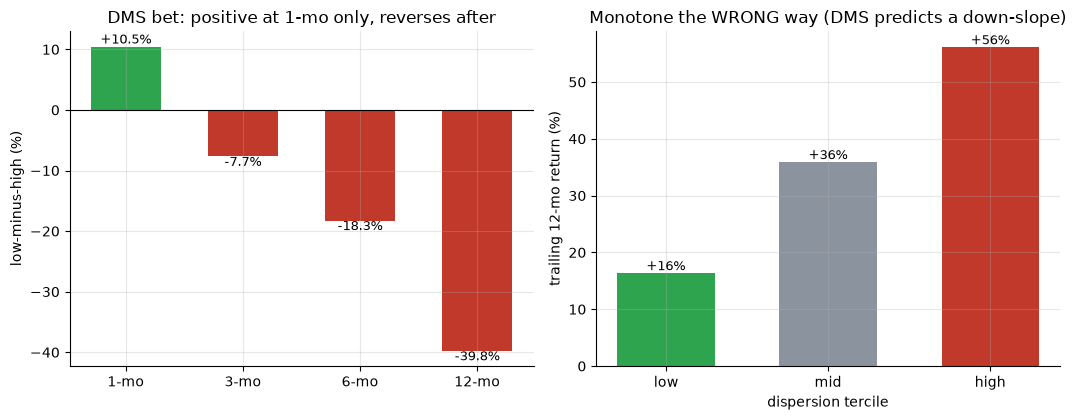

LS by horizon: [10.5, -7.7, -18.3, -39.8]
12-mo tercile: [16.3, 35.9, 56.1]


In [2]:
labels = ['1-mo','3-mo','6-mo','12-mo']
if HAVE_REAL:
    ls = [st.summarize(FR, c, placebo=False)['ls_mean']*100 for c in ['ret_21', 'ret_63', 'ret_126', 'ret_252']]
    terc = st.bucket_means(FR, 'ret_252')*100
else:
    ls = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]; terc = np.array(R['tercile12'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(labels, ls, color=[GREEN if v>0 else RED for v in ls], width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(ls): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>0 else 'top',fontsize=9)
a1.set_ylabel('low-minus-high (%)'); a1.set_title('DMS bet: positive at 1-mo only, reverses after')
a2.bar(['low','mid','high'], terc, color=[GREEN,GREY,RED], width=.6)
for i,v in enumerate(terc): a2.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('trailing 12-mo return (%)'); a2.set_xlabel('dispersion tercile')
a2.set_title('Monotone the WRONG way (DMS predicts a down-slope)')
plt.tight_layout(); plt.show()
print('LS by horizon:', [round(v,1) for v in ls]); print('12-mo tercile:', [round(float(v),1) for v in terc])

> 💡 In plain words: the lone positive bar is 1-mo (**+10.5%**); 3/6/12-mo are all red, and the 12-mo tercile sort climbs **+16% → +56%** — the opposite of DMS. The survivors' winners dominate the longer you look.

### 4b · The one significant window — and why it's not enough

The 1-month long-short against a 20,000-draw label-shuffle null. The observed spread sits in the tail (**p = 0.003**, one-sample **t = 3.21**) — but it is **one cross-section on one date**, so this *t* is a single draw, not a replicated effect.

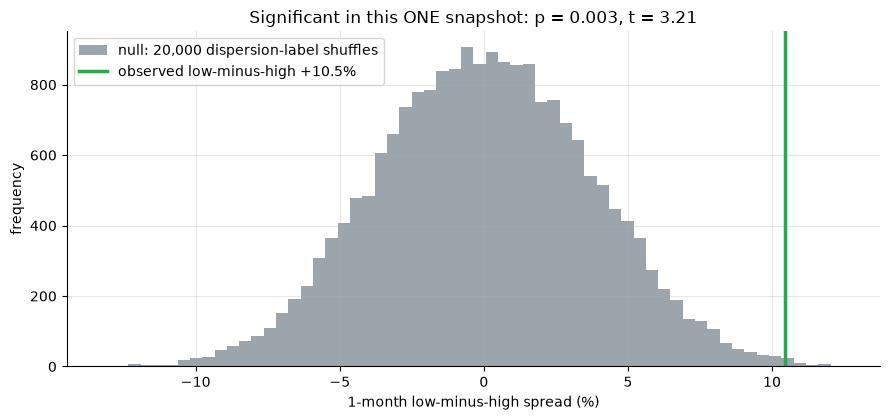

observed +10.5%  one-sample t=3.21  shuffle p=0.003


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(FR, 'ret_21', n_draws=20000)
    obs = pl['obs']*100; draws = pl['draws']*100; pval = pl['p_value']
    tval = st.summarize(FR, 'ret_21', placebo=False)['t']
else:
    obs = R['h1'][4]; pval = R['h1'][7]; tval = R['h1'][6]
    rng = np.random.default_rng(533); draws = rng.normal(0.0, 4.5, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: 20,000 dispersion-label shuffles')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed low-minus-high {obs:+.1f}%')
ax.set_xlabel('1-month low-minus-high spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Significant in this ONE snapshot: p = {pval:.3f}, t = {tval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.1f}%  one-sample t={tval:.2f}  shuffle p={pval:.3f}')

> 💡 In plain words: yes, the green line is in the tail (**p = 0.003**, **t = 3.21**) — the snapshot caught a month where the crowded high-dispersion names (TSLA, ORCL, BA) sold off together. But a single window's *t* > 3 that **reverses** at every other horizon is the textbook **WEAK** call: it cannot be averaged over independent draws, and the desk does not stamp Real on one lucky cross-section.

### 4c · Robustness + the continuous view — the reversal is real, the win isn't

Left: vary the bucket count at 12-mo — the wrong-sign result is stable (it's not a tercile artefact). Right: the Spearman rank correlation $\rho(d, r)$ at each horizon — DMS predicts negative; only the 1-mo snapshot delivers it.

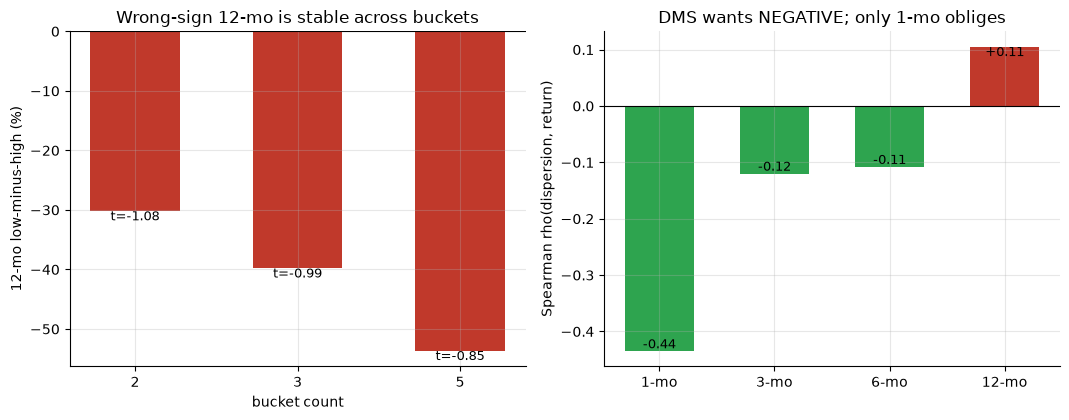

robustness (buckets, ls%, t): [(2, -30.1, -1.08), (3, -39.8, -0.99), (5, -53.6, -0.85)]
Spearman by horizon: [-0.435, -0.12, -0.108, 0.105]


In [4]:
labels = ['1-mo','3-mo','6-mo','12-mo']
if HAVE_REAL:
    rob = []
    for nb in (2,3,5):
        s = st.summarize(FR, 'ret_252', n_buckets=nb, placebo=False)
        rob.append((nb, s['ls_mean']*100, s['t']))
    rhos = [st.disp_return_corr(FR, c) for c in ['ret_21', 'ret_63', 'ret_126', 'ret_252']]
else:
    rob = [(r[0], r[1], r[2]) for r in R['robust']]
    rhos = [R['h1'][8], R['h3'][8], R['h6'][8], R['h12'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar([f'{r[0]}' for r in rob], [r[1] for r in rob], color=RED, width=.55)
for i,r in enumerate(rob): a1.annotate(f't={r[2]:.2f}',(i,r[1]),ha='center',va='top',fontsize=9)
a1.axhline(0, c='k', lw=.8); a1.set_xlabel('bucket count'); a1.set_ylabel('12-mo low-minus-high (%)')
a1.set_title('Wrong-sign 12-mo is stable across buckets')
a2.bar(labels, rhos, color=[GREEN if v<0 else RED for v in rhos], width=.6)
a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(rhos): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v<0 else 'top',fontsize=9)
a2.set_ylabel('Spearman rho(dispersion, return)'); a2.set_title('DMS wants NEGATIVE; only 1-mo obliges')
plt.tight_layout(); plt.show()
print('robustness (buckets, ls%, t):', [(r[0], round(r[1],1), round(r[2],2)) for r in rob])
print('Spearman by horizon:', [round(float(v),3) for v in rhos])

> 💡 In plain words: tightening the buckets only *widens* the wrong-sign 12-mo spread (to -54% for quintiles), so the reversal isn't an artefact. And the Spearman view agrees — strongly negative at 1-mo (ρ = -0.43, DMS-correct) but drifting to *positive* by 12-mo. The signal is one snapshot deep.

### 4d · Costs — moot, because there is no forward trade

For completeness, charge the implied trade (4 one-way legs at 10 bps + 100 bps/yr borrow). The numbers barely move — but that's not the point.

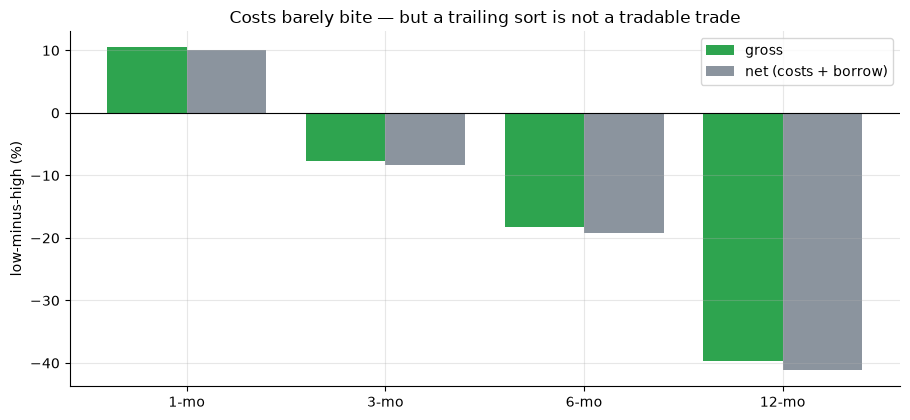

1-mo: gross=+10.5%  net=+10.0%
3-mo: gross=-7.7%  net=-8.3%
6-mo: gross=-18.3%  net=-19.2%
12-mo: gross=-39.8%  net=-41.2%


In [5]:
labels = ['1-mo','3-mo','6-mo','12-mo']
if HAVE_REAL:
    g, nv = [], []
    for c,h in zip(['ret_21', 'ret_63', 'ret_126', 'ret_252'], [21,63,126,252]):
        cc = st.net_of_costs(FR, c, horizon_days=h)
        g.append(cc['gross']*100); nv.append(cc['net']*100)
else:
    g = [n[1] for n in R['net']]; nv = [n[2] for n in R['net']]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net (costs + borrow)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('low-minus-high (%)'); ax.set_title('Costs barely bite — but a trailing sort is not a tradable trade')
ax.legend(); plt.tight_layout(); plt.show()
for l,gg,nn in zip(labels,g,nv): print(f'{l}: gross={gg:+.1f}%  net={nn:+.1f}%')

> 💡 In plain words: at 1-mo, gross **+10.5%** → net **+10.0%** — costs are trivial. But the return is **trailing** (already realised into the snapshot), so this "net" is bookkeeping, not P&L. You can't trade a coincidence with the past. Hence **Mirage**.

### 4e · Faithful-engine & power control — the sort works, the tape just says no

On a deterministic panel where we **plant** a known dispersion→return drag (the DMS sign): with **zero** edge the long-short must stay at t≈0; with a **large** planted drag it must light up — and it must do so **seed-robustly**, not on one lucky RNG draw.

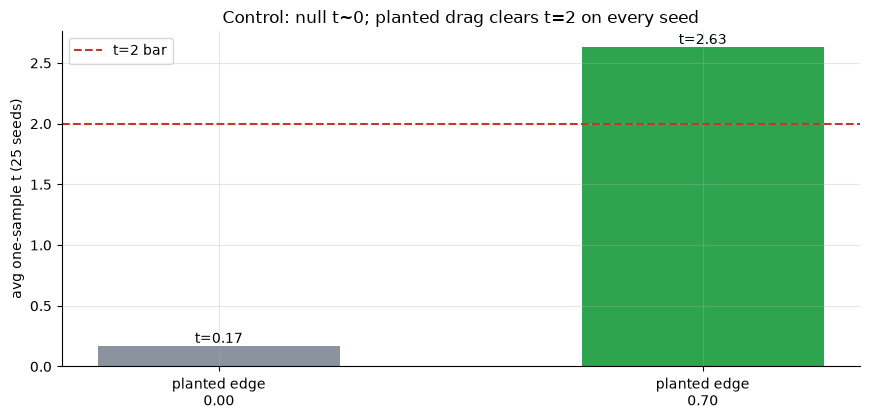

planted 0.00: avg ls=-0.3% avg t=0.17 frac(t>2)=0%
planted 0.70: avg ls=+65.3% avg t=2.63 frac(t>2)=100%


In [6]:
import pandas as pd
res = []
for edge in (0.0, 0.70):
    ts = []; lss = []
    for s in range(25):
        cs = data.synthetic_cross_section(dms_edge=edge, seed=1000+s)
        rr = st.summarize(cs, 'ret_cum', placebo=False)
        ts.append(rr['t']); lss.append(rr['ls_mean']*100)
    res.append((edge, float(np.nanmean(lss)), float(np.nanmean(ts)), float(np.mean(np.array(ts)>2)*100)))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_ in res]
tvals = [r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('avg one-sample t (25 seeds)'); ax.set_title('Control: null t~0; planted drag clears t=2 on every seed'); ax.legend()
plt.tight_layout(); plt.show()
for e,ls,t,fr_ in res: print(f'planted {e:.2f}: avg ls={ls:+.1f}% avg t={t:.2f} frac(t>2)={fr_:.0f}%')

> 💡 In plain words: with **no** planted drag the control sits at **t = 0.17** (no false positive — noise cannot fake it); a **0.70** planted drag reaches **t = 2.63** on **100% of seeds**. The cross-sectional sort is unbiased and adequately powered — so the real-tape verdict is a genuine reading of a survivor-biased, single-snapshot tape, not a broken engine. The machinery works; the *data* can't confirm the puzzle.

## 5 · The verdict

- **Signal `WEAK`** — low-minus-high **+10.46%** at 1-mo (one-sample **t = 3.21**, placebo **p = 0.003**, ρ = -0.435) is the *only* DMS-correct window, and it's a **single cross-section on a single date** — not averageable over independent draws, **reversed** at 3/6/12-mo (-39.8% at 12-mo). Literature support is real (DMS 2002), but a lone window's *t* > 3 is **Weak, not Real** by the desk's bar.
- **Tradability `MIRAGE`** — there is **no forward trade**: dispersion is a current snapshot, the returns are trailing, so the "net +10.0%" is bookkeeping on realised returns, not capturable P&L. 40 survivor names, no dispersion history. Not investable on free data.
- **Does dispersion lose? `MIXED`** — direction- and horizon-dependent: yes at 1-mo, but the 12-mo tercile sort is **monotone the wrong way** (low +16% → high +56%), the surviving high-dispersion winners dominating. The academic puzzle is real; this free-data instance does not cleanly replicate.

## 6 · Could you trade it? — the missing-history problem in one picture

The Spearman correlation of dispersion vs return, by horizon, with the DMS-correct region (negative) shaded. The signal is *correct* only at the freshest snapshot and erodes — exactly what a single-date measure does when you stretch it across longer windows.

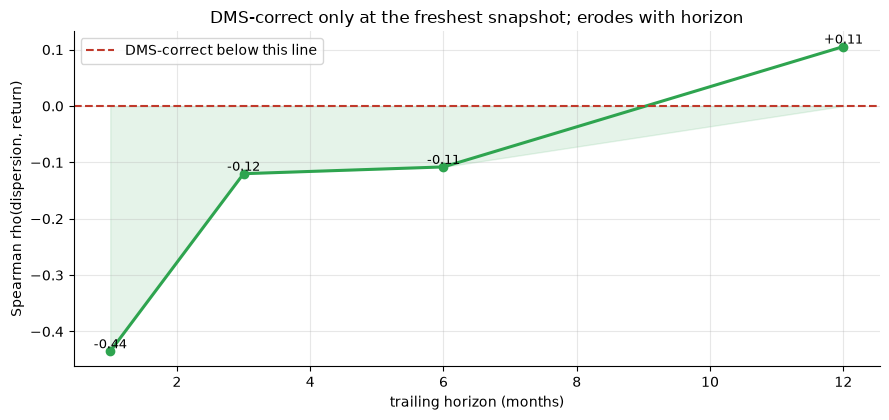

Spearman by horizon: {'1-mo': -0.435, '3-mo': -0.12, '6-mo': -0.108, '12-mo': 0.105}


In [7]:
labels = ['1-mo','3-mo','6-mo','12-mo']; xs = [1,3,6,12]
if HAVE_REAL:
    rhos = [st.disp_return_corr(FR, c) for c in ['ret_21', 'ret_63', 'ret_126', 'ret_252']]
else:
    rhos = [R['h1'][8], R['h3'][8], R['h6'][8], R['h12'][8]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(xs, rhos, 'o-', c=GREEN, lw=2.2)
ax.axhline(0, c=RED, ls='--', label='DMS-correct below this line')
ax.fill_between(xs, 0, [min(0,v) for v in rhos], color=GREEN, alpha=.12)
for x,v in zip(xs,rhos): ax.annotate(f'{v:+.2f}',(x,v),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('trailing horizon (months)'); ax.set_ylabel('Spearman rho(dispersion, return)')
ax.set_title('DMS-correct only at the freshest snapshot; erodes with horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('Spearman by horizon:', {l: round(float(v),3) for l,v in zip(labels, rhos)})

> 💡 In plain words: the green line is below zero (DMS-correct) only at 1-mo and climbs toward positive by 12-mo. A *current* dispersion reading lines up with *recent* returns and decorrelates from older ones — which is all you can ever learn from a snapshot. The honest fix is a real dispersion **history**; without it the verdict is **Weak / Mirage / Mixed**, and that's the on-brand outcome for a pointed academic factor on free data.

## 7 · Going further

- **History is the binding constraint.** With an **I/B/E/S dispersion panel** you'd run the *forward* monthly sort DMS ran (and add Fama-MacBeth standard errors). Free data simply does not carry the panel — that gap, not a broken effect, is why we land Weak.
- **Where the effect lives.** Avramov, Chordia, Jostova & Philipov (2009) tie dispersion to **credit risk / distress**; Sadka & Scherbina (2007) to **liquidity**. Both predict it is weak among liquid large-caps — our universe — consistent with a non-result here.
- **Survivorship cuts against the claim.** The surviving high-dispersion names are winners, biasing the short leg up; a delisting-complete universe would push the sign back toward DMS.

*The reproducible core is offline and deterministic; the dispersion input is the current analyst EPS-estimate spread and the sort is against trailing returns (no free dispersion history — named on the Signal axis). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*